# iris 데이터셋을 이용한 DBSCAN 클러스터링 분석

sklearn의 iris 데이터셋에 DBSCAN 알고리즘을 적용하여 밀도 기반 클러스터링을 수행

## 주요 내용
1. 데이터 로드 및 전처리
2. PCA를 이용한 차원 축소
3. K-Distance Plot을 통한 최적 epsilon 찾기
4. DBSCAN 모델 적용
5. 결과 시각화

## 필요한 라이브러리 임포트

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

## 1. 데이터 로드 및 전처리 (iris 데이터셋)

- iris 데이터셋은 178개의 샘플과 13개의 피처를 가진 데이터셋
- 각 피처는 와인의 알코올 도수, 색상 강도 등 서로 다른 단위를 가지므로 StandardScaler를 이용하여 정규화가 필수적

In [18]:
# 와인 데이터셋 로드
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# 데이터 정규화 (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"데이터 크기: {X.shape}")
print(f"\n데이터 샘플:\n{X.head()}")

데이터 크기: (150, 4)

데이터 샘플:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


## 2. 차원 축소 (PCA)

In [19]:
# 2차원 주성분으로 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"총 설명된 분산: {sum(pca.explained_variance_ratio_):.2%}")

설명된 분산 비율: [0.72962445 0.22850762]
총 설명된 분산: 95.81%


## 3. 최적의 Epsilon(eps) 찾기: K-Distance Plot

- DBSCAN의 핵심 파라미터인 epsilon(eps)을 결정하기 위해 K-Distance Plot 작성
- min_samples를 5로 가정하고 각 점에서 5번째 이웃까지의 거리를 계산
- 그래프가 급격히 꺾이는 지점(Elbow)의 Y축 값이 적절한 eps 값

그래프가 급격히 꺾이는 지점(Elbow)의 Y축 값을 확인하세요.


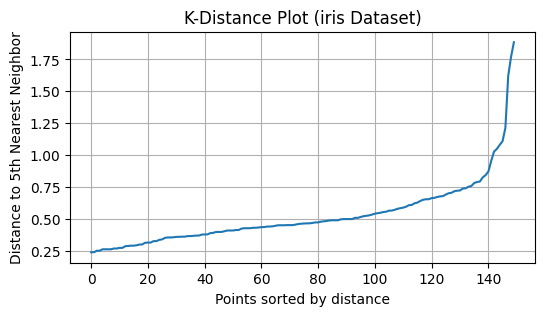

In [20]:
# 5-최근접 이웃 거리 계산
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 5번째 이웃까지의 거리를 오름차순으로 정렬
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(6, 3))
plt.plot(distances)
plt.title("K-Distance Plot (iris Dataset)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.grid(True)
print("그래프가 급격히 꺾이는 지점(Elbow)의 Y축 값을 확인하세요.")
plt.show()

## 4. DBSCAN 모델 적용

- K-Distance Plot을 참고하여 eps 값을 설정
- iris 데이터는 군집이 뚜렷한 편이므로 일반적으로 0.5~0.7 사이의 값을 사용

In [21]:
# DBSCAN 클러스터링 수행
dbscan = DBSCAN(eps=0.8, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# 클러스터 레이블 확인 (-1은 노이즈)
unique_labels = np.unique(clusters)
print(f"생성된 클러스터 라벨: {unique_labels}")

# 각 클러스터별 샘플 개수
for label in unique_labels:
    count = np.sum(clusters == label)
    if label == -1:
        print(f"노이즈(Outlier): {count}개")
    else:
        print(f"클러스터 {label}: {count}개")

생성된 클러스터 라벨: [-1  0  1]
노이즈(Outlier): 4개
클러스터 0: 49개
클러스터 1: 97개


## 5. 결과 시각화

- 노이즈(Outlier, label=-1)는 검은색 'x'로 표시

/tmp/ipykernel_2276/3933090796.py:22: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xy[:, 0], xy[:, 1],


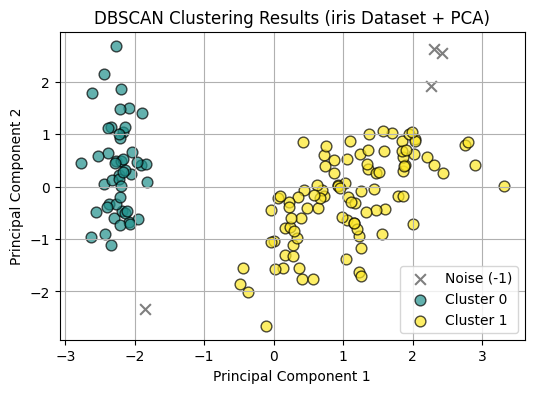

In [22]:
plt.figure(figsize=(6, 4))

# 클러스터별 색상 생성
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        # 노이즈(Outlier)는 검정색 'x'로 표시
        color = 'k'
        label_name = "Noise (-1)"
        marker = 'x'
        alpha = 0.5
    else:
        # 일반 군집
        label_name = f"Cluster {label}"
        marker = 'o'
        alpha = 0.7

    class_member_mask = (clusters == label)
    xy = X_pca[class_member_mask]

    plt.scatter(xy[:, 0], xy[:, 1],
                c=[color],
                label=label_name,
                s=60, edgecolors='k', alpha=alpha, marker=marker)

plt.title('DBSCAN Clustering Results (iris Dataset + PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()